# Mini Project - COVID-19 Exploratory Data Analysis
## Data-scope validation for an India assignment and early-outbreak snapshot analysis

**Submitted by:** Advik Singh  \n**Registration number:** RA2411056030023  \n**Dataset:** `2019_nC0v_20200121_20200126 - SUMMARY.csv`

> **Scope result:** The supplied file contains no country row labelled **India**. Therefore, an India state-wise EDA would not be defensible with this file. This notebook documents that validation and performs a transparent global / source-label analysis instead. No India values are invented or inferred.

## 1. Objectives
1. Inspect the provided CSV and quantify missing values.
2. Verify whether the requested geography (India) exists in the data.
3. Clean types and reconcile mixed timestamp formats.
4. Build a cautious representative-report timeline that avoids duplicate location rows.
5. Explore country-label and province-level patterns in the final report.

The analysis uses **NumPy, Pandas, Matplotlib, and Seaborn**, and reads only the local dataset supplied with this submission.

## 2. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})
pd.set_option('display.max_columns', 20)

print('Ready - Pandas', pd.__version__, '| NumPy', np.__version__)

Ready - Pandas 3.0.5 | NumPy 2.4.6


## 3. Load the supplied dataset

In [2]:
DATA_FILE = Path('2019_nC0v_20200121_20200126 - SUMMARY.csv')
if not DATA_FILE.exists():
    raise FileNotFoundError(f'Expected {DATA_FILE.resolve()}. Keep the CSV in the same folder as this notebook.')

raw = pd.read_csv(DATA_FILE)
print(f'Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns')
display(raw.head())

Shape: 368 rows x 7 columns


,Province/State,Country,Date last updated,Confirmed,Suspected,Recovered,Deaths
0,Shanghai,Mainland China,1/21/2020,9.0,10.0,NaN,NaN
1,Yunnan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
2,Beijing,Mainland China,1/21/2020,10.0,NaN,NaN,NaN
3,Taiwan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN
4,Jilin,Mainland China,1/21/2020,NaN,1.0,NaN,NaN


## 4. Initial data-quality audit
Blank cells are counted before any cleaning, so missingness is not hidden by later transformations.

In [3]:
audit = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'non_null': raw.notna().sum(),
    'missing': raw.isna().sum(),
})
audit['missing_pct'] = (100 * audit['missing'] / len(raw)).round(1)
display(audit)
print('Date strings include both date-only and date-time forms:', raw['Date last updated'].nunique(), 'unique values')

,dtype,non_null,missing,missing_pct
Province/State,str,304,64,17.4
Country,str,368,0,0.0
Date last updated,str,368,0,0.0
Confirmed,float64,339,29,7.9
Suspected,float64,88,280,76.1
Recovered,float64,36,332,90.2
Deaths,float64,24,344,93.5


Date strings include both date-only and date-time forms: 10 unique values


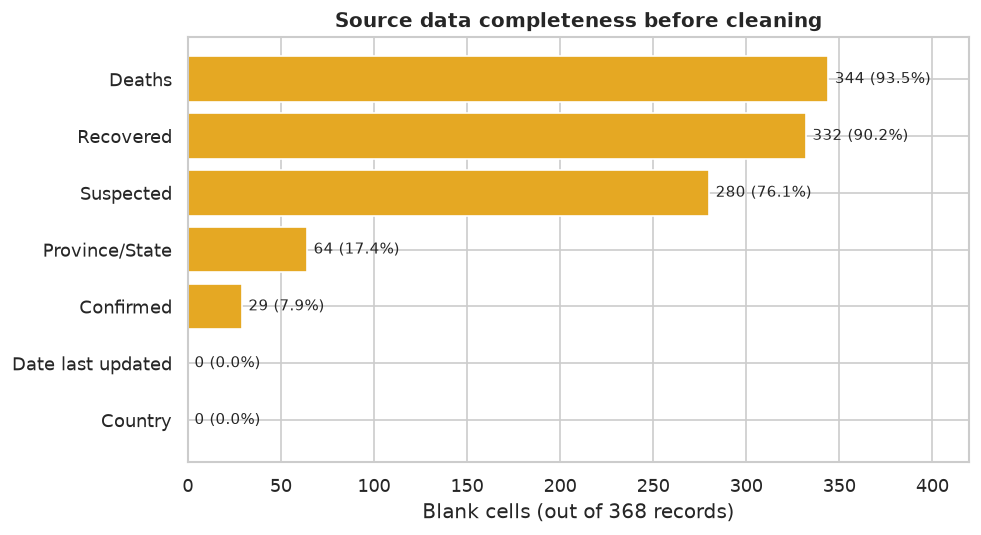

In [4]:
missing = raw.isna().sum().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8.4, 4.6))
bars = ax.barh(missing.index, missing.values, color=['#2176AE' if x == 0 else '#E5A823' for x in missing.values])
ax.set_title('Source data completeness before cleaning')
ax.set_xlabel('Blank cells (out of 368 records)'); ax.set_ylabel('')
ax.bar_label(bars, labels=[f'{int(v)} ({v / len(raw):.1%})' for v in missing.values], padding=4, fontsize=9)
ax.set_xlim(0, max(missing.values) * 1.22)
plt.show()

## 5. India coverage check
The project filename refers to India, but the requested data must be checked before geographical conclusions are made.

In [5]:
country_values = sorted(raw['Country'].dropna().astype(str).str.strip().unique())
india_rows = raw[raw['Country'].astype(str).str.strip().str.fullmatch('India', case=False, na=False)]
print('Country labels in raw data:', len(country_values))
print(country_values)
print(f'India-labelled records: {len(india_rows)}')
if india_rows.empty:
    print('SCOPE RESULT: India is not present. The remaining analysis is global/source-label EDA only.')
else:
    display(india_rows)

Country labels in raw data: 21
['Australia', 'Brazil', 'Canada', 'China', 'Colombia', 'France', 'Hong Kong', 'Japan', 'Macau', 'Mainland China', 'Malaysia', 'Mexico', 'Nepal', 'Philippines', 'Singapore', 'South Korea', 'Taiwan', 'Thailand', 'US', 'United States', 'Vietnam']
India-labelled records: 0
SCOPE RESULT: India is not present. The remaining analysis is global/source-label EDA only.


## 6. Clean and standardise
- Parse mixed timestamps with a compatible mixed-format fallback.
- Convert health metrics to numeric values while preserving missing values for the audit.
- Standardise the `US` label to `United States` for consistent country naming.
- Keep `Mainland China`, Hong Kong, Macau, and Taiwan as the source labels; their meaning is not reinterpreted here.

For descriptive totals, Pandas sums the numeric values recorded in the source. A blank value is still treated as missing in the quality discussion.

In [6]:
df = raw.rename(columns={
    'Province/State': 'province', 'Country': 'country',
    'Date last updated': 'reported_at_raw', 'Confirmed': 'confirmed',
    'Suspected': 'suspected', 'Recovered': 'recovered', 'Deaths': 'deaths'
}).copy()
metrics = ['confirmed', 'suspected', 'recovered', 'deaths']
for metric in metrics:
    df[metric] = pd.to_numeric(df[metric], errors='coerce')
try:
    parsed_dates = pd.to_datetime(df['reported_at_raw'], format='mixed', errors='coerce')
except (TypeError, ValueError):
    parsed_dates = pd.Series(pd.NaT, index=df.index)
# Fallback keeps the notebook compatible with older Pandas versions.
if parsed_dates.isna().any():
    parsed_dates = df['reported_at_raw'].map(lambda value: pd.to_datetime(value, errors='coerce'))
df['reported_at'] = parsed_dates
df['date'] = df['reported_at'].dt.normalize()
df['country_label'] = df['country'].astype(str).str.strip().replace({'US': 'United States'})
df['province_label'] = df['province'].fillna('Country-level report').astype(str).str.strip()
df['location_key'] = df['country_label'] + ' | ' + df['province_label']

print('Unparsed timestamps:', df['reported_at'].isna().sum())
print('Data window:', df['reported_at'].min(), 'to', df['reported_at'].max())
display(df.head())

Unparsed timestamps: 0
Data window: 2020-01-21 00:00:00 to 2020-01-26 11:00:00


,province,country,reported_at_raw,confirmed,suspected,recovered,deaths,reported_at,date,country_label,province_label,location_key
0,Shanghai,Mainland China,1/21/2020,9.0,10.0,NaN,NaN,2020-01-21,2020-01-21,Mainland China,Shanghai,Mainland China | Shanghai
1,Yunnan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN,2020-01-21,2020-01-21,Mainland China,Yunnan,Mainland China | Yunnan
2,Beijing,Mainland China,1/21/2020,10.0,NaN,NaN,NaN,2020-01-21,2020-01-21,Mainland China,Beijing,Mainland China | Beijing
3,Taiwan,Mainland China,1/21/2020,1.0,NaN,NaN,NaN,2020-01-21,2020-01-21,Mainland China,Taiwan,Mainland China | Taiwan
4,Jilin,Mainland China,1/21/2020,NaN,1.0,NaN,NaN,2020-01-21,2020-01-21,Mainland China,Jilin,Mainland China | Jilin


## 7. Choose comparable daily reports
The source includes several same-day timestamps. On 24 and 25 January, some records are partial supplements and one timestamp repeats locations. Adding every same-day row would double-count places. For each calendar day, the notebook selects the **largest timestamp group with one row per location**; where equally complete groups exist, it takes the later one. This is a reproducible EDA convention, not an official surveillance reconstruction.

In [7]:
snapshot_audit = (
    df.groupby(['date', 'reported_at'], as_index=False)
      .agg(rows=('location_key', 'size'),
           unique_locations=('location_key', 'nunique'),
           reported_confirmed=('confirmed', 'sum'))
      .sort_values('reported_at')
)
snapshot_audit['duplicate_rows'] = snapshot_audit['rows'] - snapshot_audit['unique_locations']
display(snapshot_audit)

clean_candidates = snapshot_audit.query('duplicate_rows == 0').copy()
selected = (clean_candidates
    .sort_values(['date', 'unique_locations', 'reported_at'])
    .groupby('date', group_keys=False).tail(1)
    .sort_values('date').reset_index(drop=True))
print('Selected representative reports:')
display(selected[['date', 'reported_at', 'rows', 'unique_locations', 'reported_confirmed']])

,date,reported_at,rows,unique_locations,reported_confirmed,duplicate_rows
0,2020-01-21,2020-01-21 00:00:00,27,27,332.0,0
1,2020-01-22,2020-01-22 12:00:00,38,38,555.0,0
2,2020-01-23,2020-01-23 12:00:00,46,46,653.0,0
3,2020-01-24,2020-01-24 00:00:00,38,38,881.0,0
4,2020-01-24,2020-01-24 12:00:00,40,40,939.0,0
5,2020-01-24,2020-01-24 16:00:00,1,1,2.0,0
6,2020-01-25,2020-01-25 00:00:00,44,44,1354.0,0
7,2020-01-25,2020-01-25 12:00:00,86,44,2301.0,42
8,2020-01-25,2020-01-25 22:00:00,2,2,1156.0,0
9,2020-01-26,2020-01-26 11:00:00,46,46,2116.0,0


Selected representative reports:


,date,reported_at,rows,unique_locations,reported_confirmed
0,2020-01-21,2020-01-21 00:00:00,27,27,332.0
1,2020-01-22,2020-01-22 12:00:00,38,38,555.0
2,2020-01-23,2020-01-23 12:00:00,46,46,653.0
3,2020-01-24,2020-01-24 12:00:00,40,40,939.0
4,2020-01-25,2020-01-25 00:00:00,44,44,1354.0
5,2020-01-26,2020-01-26 11:00:00,46,46,2116.0


In [8]:
representative = df.merge(selected[['date', 'reported_at']], on=['date', 'reported_at'], how='inner')
timeline = (representative.groupby(['date', 'reported_at'], as_index=False)[metrics]
              .sum().fillna(0).sort_values('date').reset_index(drop=True))
timeline[metrics] = timeline[metrics].astype(int)
timeline['reported_confirmed_change'] = timeline['confirmed'].diff().fillna(timeline['confirmed']).astype(int)
timeline['growth_pct'] = (timeline['confirmed'].pct_change() * 100).round(1)
timeline['recovery_rate_pct'] = (100 * timeline['recovered'] / timeline['confirmed']).round(2)
timeline['reported_death_rate_pct'] = (100 * timeline['deaths'] / timeline['confirmed']).round(2)
display(timeline)

,date,reported_at,confirmed,suspected,recovered,deaths,reported_confirmed_change,growth_pct,recovery_rate_pct,reported_death_rate_pct
0,2020-01-21,2020-01-21 00:00:00,332,169,0,0,332,NaN,0.00,0.00
1,2020-01-22,2020-01-22 12:00:00,555,137,0,0,223,67.2,0.00,0.00
2,2020-01-23,2020-01-23 12:00:00,653,144,30,18,98,17.7,4.59,2.76
3,2020-01-24,2020-01-24 12:00:00,939,159,36,26,286,43.8,3.83,2.77
4,2020-01-25,2020-01-25 00:00:00,1354,73,38,41,415,44.2,2.81,3.03
5,2020-01-26,2020-01-26 11:00:00,2116,383,52,56,762,56.3,2.46,2.65


## 8. Final representative snapshot

In [9]:
final_time = timeline['reported_at'].max()
final_snapshot = representative[representative['reported_at'].eq(final_time)].copy()
country_totals = (final_snapshot.groupby('country_label', as_index=False)[metrics]
                  .sum().fillna(0).sort_values('confirmed', ascending=False).reset_index(drop=True))
country_totals[metrics] = country_totals[metrics].astype(int)
country_totals['share_of_final_pct'] = (100 * country_totals['confirmed'] / country_totals['confirmed'].sum()).round(2)
province_totals = (final_snapshot[final_snapshot['country_label'].eq('Mainland China')]
                   .groupby('province_label', as_index=False)[metrics]
                   .sum().fillna(0).sort_values('confirmed', ascending=False).reset_index(drop=True))
province_totals[metrics] = province_totals[metrics].astype(int)
province_totals['share_of_mainland_china_pct'] = (100 * province_totals['confirmed'] / province_totals['confirmed'].sum()).round(2)

final_totals = country_totals[metrics].sum()
print('Final representative report:', final_time)
for metric, value in final_totals.items():
    print(f'  {metric.title():<10}: {value:,}')
display(country_totals)

Final representative report: 2020-01-26 11:00:00
  Confirmed : 2,116
  Suspected : 383
  Recovered : 52
  Deaths    : 56


,country_label,confirmed,suspected,recovered,deaths,share_of_final_pct
0,Mainland China,2062,139,49,56,97.45
1,Hong Kong,8,244,0,0,0.38
2,Thailand,8,0,2,0,0.38
3,Macau,5,0,0,0,0.24
4,Australia,4,0,0,0,0.19
5,Malaysia,4,0,0,0,0.19
6,Japan,4,0,1,0,0.19
7,Taiwan,4,0,0,0,0.19
8,Singapore,4,0,0,0,0.19
9,United States,3,0,0,0,0.14


## 9. Visual exploration

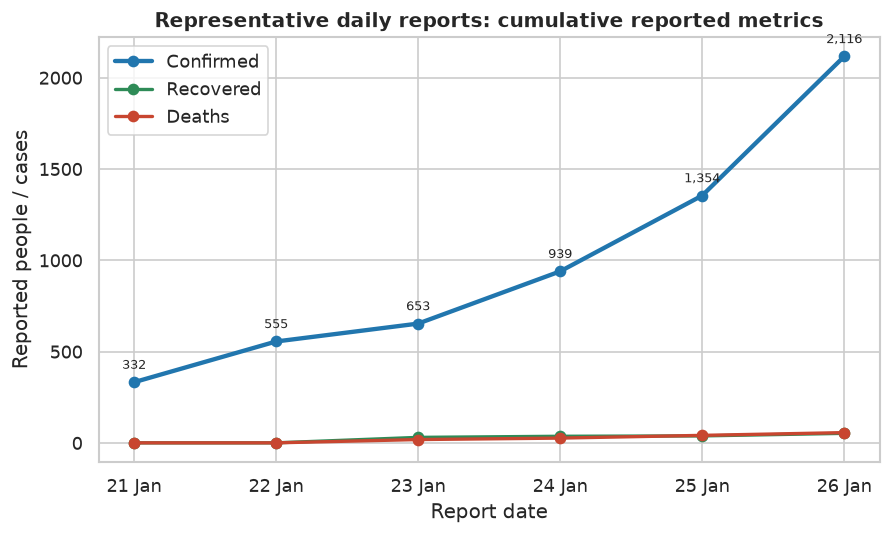

In [10]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.plot(timeline['date'], timeline['confirmed'], marker='o', lw=2.6, color='#2176AE', label='Confirmed')
ax.plot(timeline['date'], timeline['recovered'], marker='o', lw=2, color='#2E8B57', label='Recovered')
ax.plot(timeline['date'], timeline['deaths'], marker='o', lw=2, color='#C84630', label='Deaths')
for _, row in timeline.iterrows():
    ax.annotate(f"{row['confirmed']:,}", (row['date'], row['confirmed']), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8)
ax.set_title('Representative daily reports: cumulative reported metrics')
ax.set_xlabel('Report date'); ax.set_ylabel('Reported people / cases')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.legend(); plt.show()

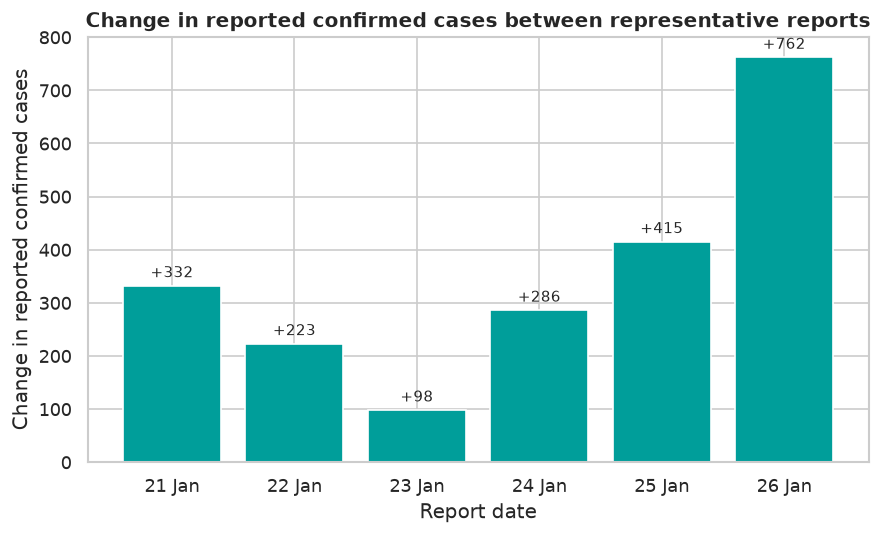

In [11]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
bars = ax.bar(timeline['date'].dt.strftime('%d %b'), timeline['reported_confirmed_change'], color='#009E9A')
ax.bar_label(bars, labels=[f"+{int(v):,}" for v in timeline['reported_confirmed_change']], padding=3, fontsize=9)
ax.set_title('Change in reported confirmed cases between representative reports')
ax.set_xlabel('Report date'); ax.set_ylabel('Change in reported confirmed cases')
plt.show()

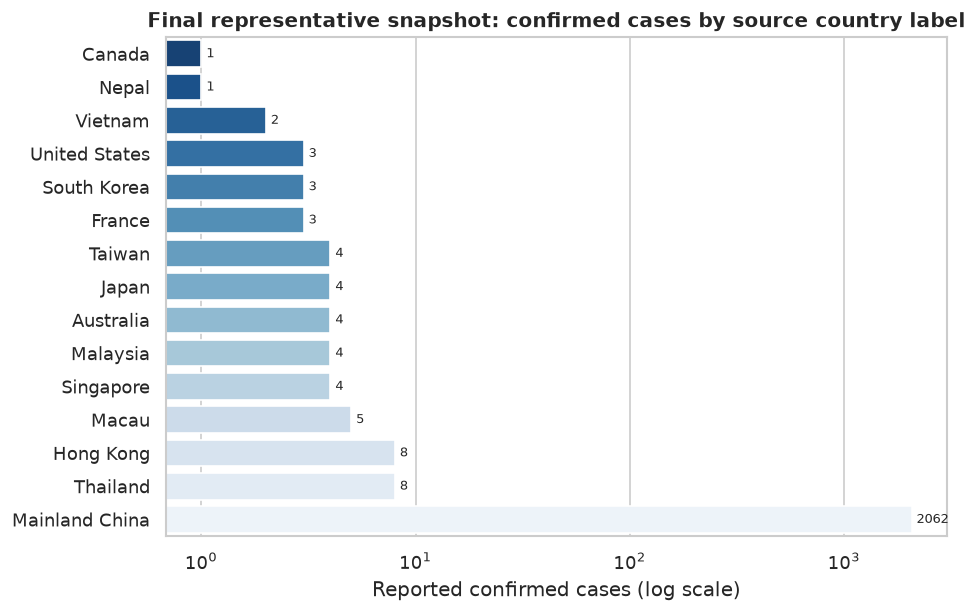

In [12]:
country_plot = country_totals[country_totals['confirmed'].gt(0)].sort_values('confirmed')
fig, ax = plt.subplots(figsize=(8.4, 5.4))
sns.barplot(data=country_plot, y='country_label', x='confirmed', hue='country_label', palette='Blues_r', legend=False, ax=ax)
ax.set_xscale('log')
ax.set_title('Final representative snapshot: confirmed cases by source country label')
ax.set_xlabel('Reported confirmed cases (log scale)'); ax.set_ylabel('')
for bar in ax.patches:
    ax.annotate(f'{bar.get_width():.0f}', (bar.get_width(), bar.get_y() + bar.get_height()/2), xytext=(3, 0), textcoords='offset points', va='center', fontsize=8)
plt.show()

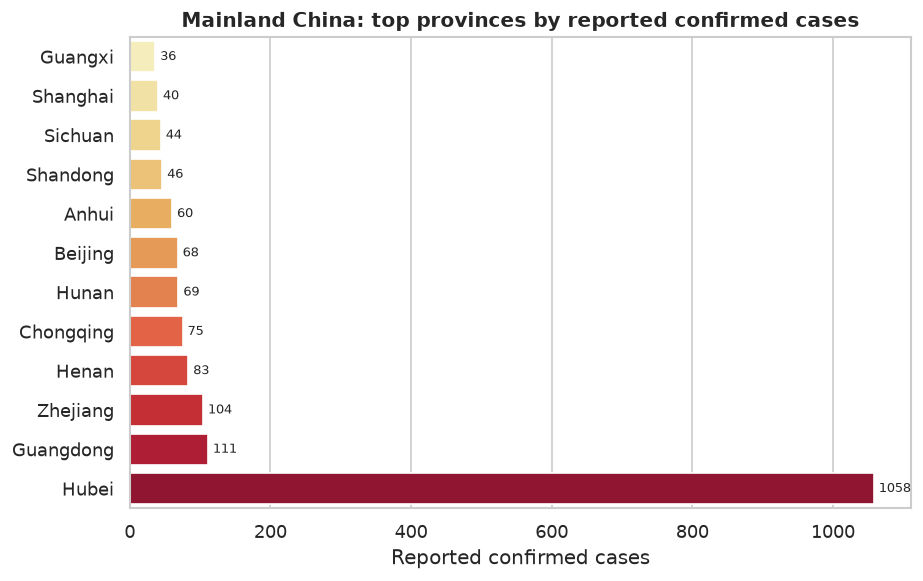

In [13]:
top_provinces = province_totals.head(12).sort_values('confirmed')
fig, ax = plt.subplots(figsize=(8.4, 5.1))
sns.barplot(data=top_provinces, y='province_label', x='confirmed', hue='province_label', palette='YlOrRd', legend=False, ax=ax)
ax.set_title('Mainland China: top provinces by reported confirmed cases')
ax.set_xlabel('Reported confirmed cases'); ax.set_ylabel('')
for bar in ax.patches:
    ax.annotate(f'{bar.get_width():.0f}', (bar.get_width(), bar.get_y() + bar.get_height()/2), xytext=(3, 0), textcoords='offset points', va='center', fontsize=8)
plt.show()

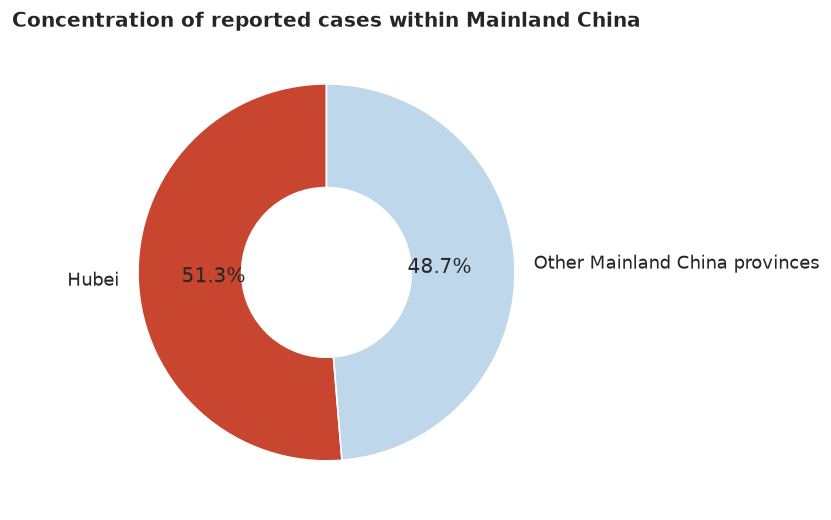

In [14]:
hubei = int(province_totals.loc[province_totals['province_label'].eq('Hubei'), 'confirmed'].iloc[0])
mainland_total = int(province_totals['confirmed'].sum())
fig, ax = plt.subplots(figsize=(7, 5.1))
ax.pie([hubei, mainland_total-hubei], labels=['Hubei', 'Other Mainland China provinces'], autopct='%1.1f%%',
       startangle=90, colors=['#C84630', '#BFD7EA'], wedgeprops={'width': 0.55, 'edgecolor': 'white'})
ax.set_title('Concentration of reported cases within Mainland China')
plt.show()

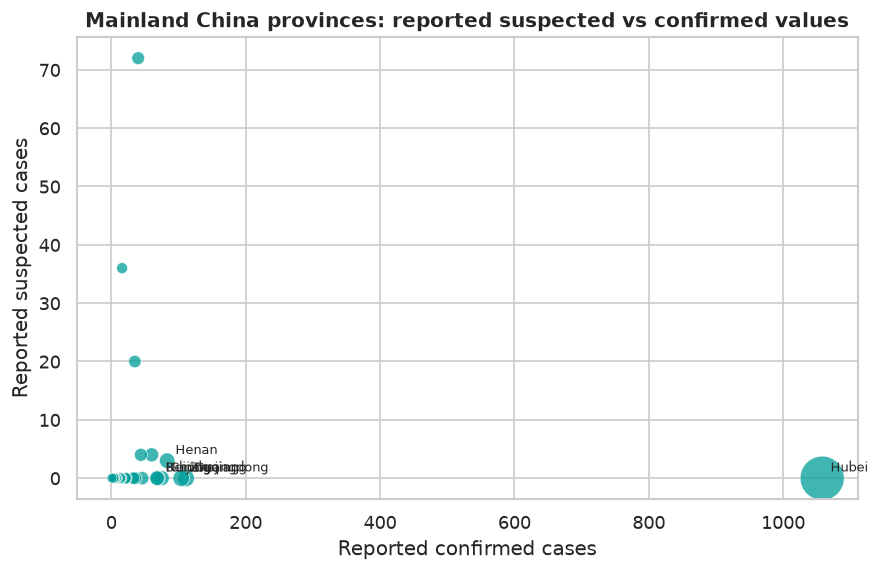

In [15]:
scatter = province_totals[(province_totals['confirmed'] > 0) | (province_totals['suspected'] > 0)].copy()
fig, ax = plt.subplots(figsize=(8.4, 5.0))
sns.scatterplot(data=scatter, x='confirmed', y='suspected', size='confirmed', sizes=(35, 700), color='#009E9A', alpha=0.75, legend=False, ax=ax)
for _, row in scatter.nlargest(7, 'confirmed').iterrows():
    ax.annotate(row['province_label'], (row['confirmed'], row['suspected']), xytext=(5, 4), textcoords='offset points', fontsize=8)
ax.set_title('Mainland China provinces: reported suspected vs confirmed values')
ax.set_xlabel('Reported confirmed cases'); ax.set_ylabel('Reported suspected cases')
plt.show()

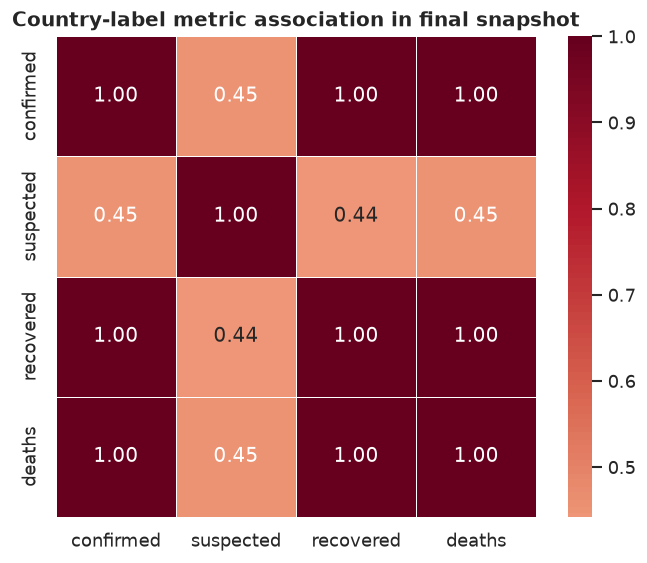

In [16]:
corr = country_totals[metrics].corr()
fig, ax = plt.subplots(figsize=(6.8, 5.2))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Country-label metric association in final snapshot')
plt.show()

## 10. Findings
- The file contains **368 records** across **21 source country labels** and six report dates (21-26 January 2020).
- **India-labelled records = 0.** The supplied data cannot support India state-wise totals, trends, or recommendations.
- The representative reports show confirmed values rising from **332** to **2,116**. Because report times and missing fields differ, this is a descriptive source trend rather than a validated epidemiological time series.
- In the final representative report, the source label **Mainland China** accounts for the large majority of recorded confirmed values. Hubei is the largest province in that label group.
- Missingness is substantial for `Suspected`, `Recovered`, and `Deaths`; a blank should not be interpreted as a clinical zero.

## 11. Limitations and reproducibility
1. **Geographic scope:** India is absent, so this is not a substitute for a real India COVID-19 EDA.
2. **Update structure:** Mixed timestamps and repeated locations on 24-25 January require a representative-snapshot rule.
3. **Completeness:** Reporting definitions, coverage, testing levels, and missing fields are not documented in the CSV.
4. **Interpretation:** The figures are descriptive. They do not establish causes, rates adjusted for population, or predictions.

To reproduce: place this notebook and the CSV in the same folder, then run with Python packages `pandas`, `numpy`, `matplotlib`, and `seaborn`.

## 12. Data provenance
- Local source file: `2019_nC0v_20200121_20200126 - SUMMARY.csv` (provided for this mini project).
- The calculations above use only values in that file.
- Submission prepared by **Advik Singh** (Registration No. **RA2411056030023**).